# **Fairness Audit of Demographic Bias in Drug Adverse Event Severity**

This project uses FAERS pharmacovigilance data to build a machine learning model that predicts whether an adverse drug event is serious or not. It also includes a fairness analysis to evaluate whether model performance differs across demographic groups, particularly sex and age, using standard fairness metrics to detect potential bias in healthcare predictions.


### Importing neccesary libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle # Saving and loading
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True) # making folder to save plots



# ── Setting random seed everywhere for reproducibility ───────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [13]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# ── Seting our data path here ──────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/Ethics project/ASCII/"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## FAERS Data Files

* `DEMO (Demographic Data)`: Contains patient and report information, including age, sex, report date, country, and unique case identifiers.

* `OUTC (Outcomes Data`): Records the outcomes of adverse events, such as death, hospitalization, disability, life-threatening events, and other serious outcomes.

* `REAC (Reaction Data)`: Lists the adverse reactions reported for each case using standardized MedDRA medical terminology.

* `DRUG (Drug Data)`: Contains information about medications involved in each report, including drug names, active ingredients, and their role (e.g., primary suspect or concomitant drug).


##### Together, these files provide demographic, clinical, outcome, and medication information that can be linked through case identifiers to build and evaluate adverse event prediction models.
---

In [14]:
# ============================================================
# STEP 1: LOAD ALL 4 RAW FILES
# ============================================================


print("=" * 60)
print("STEP 1: LOADING RAW FILES")
print("=" * 60)

try:
    demo = pd.read_csv(DATA_PATH + 'DEMO26Q1.txt',
                       sep='$', encoding='latin-1',
                       low_memory=False)
    print(f"DEMO loaded : {len(demo):>8,} rows × {demo.shape[1]} cols")

    outc = pd.read_csv(DATA_PATH + 'OUTC26Q1.txt',
                       sep='$', encoding='latin-1',
                       low_memory=False)
    print(f"OUTC loaded : {len(outc):>8,} rows × {outc.shape[1]} cols")

    reac = pd.read_csv(DATA_PATH + 'REAC26Q1.txt',
                       sep='$', encoding='latin-1',
                       low_memory=False)
    print(f"REAC loaded : {len(reac):>8,} rows × {reac.shape[1]} cols")

    drug = pd.read_csv(DATA_PATH + 'DRUG26Q1.txt',
                       sep='$', encoding='latin-1',
                       low_memory=False)
    print(f"DRUG loaded : {len(drug):>8,} rows × {drug.shape[1]} cols")

except FileNotFoundError as e:
    print(f"ERROR: {e}")
    raise

# ── Strip whitespace from ALL column names ───────────────────
for df in [demo, outc, reac, drug]:
    df.columns = df.columns.str.strip().str.lower()

print("\nColumn names after cleaning:")
print(f"  DEMO: {demo.columns.tolist()[:8]} ...")
print(f"  OUTC: {outc.columns.tolist()}")
print(f"  REAC: {reac.columns.tolist()}")
print(f"  DRUG: {drug.columns.tolist()[:8]} ...")

STEP 1: LOADING RAW FILES
DEMO loaded :  397,224 rows × 25 cols
OUTC loaded :  291,580 rows × 3 cols
REAC loaded : 1,330,675 rows × 4 cols
DRUG loaded : 1,703,210 rows × 20 cols

Column names after cleaning:
  DEMO: ['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt'] ...
  OUTC: ['primaryid', 'caseid', 'outc_cod']
  REAC: ['primaryid', 'caseid', 'pt', 'drug_rec_act']
  DRUG: ['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route'] ...


In [15]:
demo.head(5)

,primaryid,caseid,caseversion,i_f_code,event_dt,mfr_dt,init_fda_dt,fda_dt,rept_cod,auth_num,...,age_grp,sex,e_sub,wt,wt_cod,rept_dt,to_mfr,occp_cod,reporter_country,occr_country
0,1001678127,10016781,27,F,20120330.0,20260121,20140318,20260203,EXP,NaN,...,NaN,F,Y,NaN,NaN,20260203,NaN,HP,CA,CA
1,100293665,10029366,5,F,NaN,20251229,20140322,20260106,EXP,NaN,...,NaN,M,Y,NaN,NaN,20260106,NaN,HP,AU,AU
2,1005450711,10054507,11,F,NaN,20260114,20140402,20260120,PER,NaN,...,E,F,Y,NaN,NaN,20260120,NaN,MD,US,US
3,1005762126,10057621,26,F,20140204.0,20260112,20140404,20260127,EXP,NaN,...,A,M,Y,53.0,KG,20260127,NaN,MD,CA,CA
4,100670805,10067080,5,F,NaN,20140428,20260119,20260119,PER,NaN,...,NaN,M,Y,NaN,NaN,20260119,NaN,MD,TR,US


In [16]:
outc.head(5)

,primaryid,caseid,outc_cod
0,1001678127,10016781,OT
1,100293665,10029366,OT
2,1005762126,10057621,HO
3,100670805,10067080,OT
4,100716524,10071652,OT


In [17]:
reac.head(5)

,primaryid,caseid,pt,drug_rec_act
0,1001678127,10016781,Erythema,NaN
1,1001678127,10016781,Blood creatine increased,NaN
2,1001678127,10016781,Fall,NaN
3,1001678127,10016781,Scab,NaN
4,1001678127,10016781,Rosacea,NaN


In [18]:
drug.head(5)

,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,cum_dose_unit,dechal,rechal,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq
0,1001678127,10016781,1,PS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Subcutaneous,"UNK, TID (cont 02 weeks post 01st LAR)",NaN,NaN,Y,U,NaN,NaN,19667.0,NaN,NaN,NaN,TID
1,1001678127,10016781,2,SS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO",NaN,NaN,Y,U,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
2,1001678127,10016781,3,SS,SANDOSTATIN,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO",NaN,NaN,Y,U,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
3,1001678127,10016781,4,SS,SANDOSTATIN LAR DEPOT,OCTREOTIDE ACETATE,1,Intramuscular,"20 mg, QMO (once a month)",NaN,NaN,U,NaN,NaN,NaN,19667.0,20.0,MG,NaN,/MONTH
4,1001678127,10016781,5,SS,SANDOSTATIN LAR DEPOT,OCTREOTIDE ACETATE,1,Intramuscular,"30 mg, QMO (once a month)",NaN,NaN,U,NaN,NaN,NaN,19667.0,30.0,MG,NaN,/MONTH


---
## **Reason behind choosing `Serious` and `Not-Serious` labels**

We classify drug reactions as Serious (1) if they result in any of the following six outcomes:

* `HO` = Hospitalization
* `DE` = Death
* `DS` = Disability
* `LT` = Life-threatening
* `CA` = Birth defect
* `RI` = Medical intervention needed

All other reactions that do not meet these criteria are classified as Not Serious (0) such as:

* `OT` = Other


> We selected this classification based on the `ICH E2A Guidelines (International Council for Harmonisation)` and standards set by major regulatory bodies like the `FDA (USA)` and `EMA (Europe)`.

> According to these global pharmacovigilance rules, an adverse event is legally defined as a "Serious Adverse Event" (SAE) only if it results in one of the six specific outcomes listed above.

> This distinction is critical because SAEs require mandatory, expedited reporting to health authorities, whereas non-serious events are typically monitored through periodic safety updates.


#### Using this standard ensures our ML model aligns with real-world medical and legal requirements for drug safety monitoring.
---

In [19]:
# ============================================================
# STEP 2: BUILD TARGET VARIABLE
# ============================================================

print("\n" + "=" * 60)
print("STEP 2: BUILD TARGET VARIABLE FROM OUTC")
print("=" * 60)

SERIOUS_CODES = {'de', 'lt', 'ho', 'ds', 'ca', 'ri'}

# Strip whitespace and lowercase all outcome codes
outc['outc_cod'] = outc['outc_cod'].fillna('').str.strip().str.lower()

# One row per primaryid serious if ANY code is DE/LT/HO etc
target = (
    outc.groupby('primaryid')['outc_cod']
    .apply(lambda codes: 1 if len(set(codes) & SERIOUS_CODES) > 0 else 0)
    .reset_index()
    .rename(columns={'outc_cod': 'serious'})
)

print(f"Total reports with outcome data : {len(target):,}")
print(f"Serious (1)                     : {target['serious'].sum():,}  "
      f"({target['serious'].mean():.1%})")
print(f"Not serious (0)                 : {(target['serious']==0).sum():,}  "
      f"({(target['serious']==0).mean():.1%})")


STEP 2: BUILD TARGET VARIABLE FROM OUTC
Total reports with outcome data : 218,055
Serious (1)                     : 112,252  (51.5%)
Not serious (0)                 : 105,803  (48.5%)


---
## **Demo file Cleaning**
* Standardized sex and age_cod columns by removing
extra spaces and converting values to uppercase.

* Converted all age values into a common unit (years) using age_cod multipliers (e.g., months, weeks, days → years).

* Created a new column age_years containing the converted age values.

* Removed unrealistic age values:
  * Excluded records with age < 1 year
  * Excluded records with age > 110 years (likely data errors)

* Filtered dataset to keep only valid sex values (M and F), removing unknown or missing entries.
---

In [20]:
 # ============================================================
# STEP 3: CLEAN DEMOGRAPHICS
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: CLEAN DEMOGRAPHICS")
print("=" * 60)

# ── Strip whitespace from string columns ─────────────────────
demo['sex']     = demo['sex'].astype(str).str.strip().str.upper()
demo['age_cod'] = demo['age_cod'].astype(str).str.strip().str.upper()

# ── Convert age to years ──────────────────────────────────────
# age_cod tells us the unit: YR=years, MON=months, etc.
AGE_MULTIPLIER = {
    'YR' : 1,
    'MON': 1 / 12,
    'WK' : 1 / 52,
    'DY' : 1 / 365,
    'DEC': 10,
    'HR' : 1 / 8760
}

def convert_age(row):
    try:
        age     = float(row['age'])
        age_cod = str(row['age_cod']).strip().upper()
        mult    = AGE_MULTIPLIER.get(age_cod, None)
        if mult is None or pd.isna(age):
            return np.nan
        return age * mult
    except (ValueError, TypeError):
        return np.nan

demo['age_years'] = demo.apply(convert_age, axis=1)

print(f"Age conversion done")
print(f"  Rows before age filter : {len(demo):,}")

# ── Remove impossible ages ────────────────────────────────────
# Age < 1: neonates with complex reporting — exclude
# Age > 110: data entry errors
demo = demo[
    (demo['age_years'] >= 1) &
    (demo['age_years'] <= 110)
].copy()

print(f"  Rows after age filter  : {len(demo):,}")

# ── Keep only known sex: M or F ──────────────────────────────
# UNK, NS (not specified), and others cannot be audited
print(f"Sex distribution before filter:")
print(f"  {demo['sex'].value_counts().to_dict()}")

demo = demo[demo['sex'].isin(['M', 'F'])].copy()

print(f"Rows after sex filter  : {len(demo):,}")
print(f"  Male   : {(demo['sex']=='M').sum():,}")
print(f"  Female : {(demo['sex']=='F').sum():,}")


STEP 3: CLEAN DEMOGRAPHICS
Age conversion done
  Rows before age filter : 397,224
  Rows after age filter  : 244,345
Sex distribution before filter:
  {'F': 135531, 'M': 89246, 'NAN': 19568}
Rows after sex filter  : 224,777
  Male   : 89,246
  Female : 135,531


In [21]:
# ── Keep only the columns we need ───────────────────────────
demo_clean = demo[['primaryid', 'age_years', 'sex']].copy()

demo_clean.head(5)

,primaryid,age_years,sex
0,1001678127,56.0,F
1,100293665,32.0,M
2,1005450711,68.0,F
3,1005762126,57.0,M
6,1007844154,65.0,F




---


## **Cleaning Reaction file**
* Reaction terms were standardized by converting them to lowercase and removing missing values.

* Since multiple reactions can be reported for a single case, only the first recorded reaction was retained, ensuring one reaction entry per report.

*In FAERS, one patient case can have many reactions (e.g., nausea, headache, rash). But most machine learning models require a single label per row. If we kept all reactions:*

* One case would appear multiple times → data duplication
* The same patient would influence the model more than others → bias
* It would break the structure needed for a clean supervised learning dataset

---

In [22]:
# ============================================================
# STEP 4: CLEAN REACTIONS
# ============================================================
# Each report can have MULTIPLE reactions
# We take only the FIRST reaction per report
# This keeps one row per report after merging
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: CLEAN REAC (REACTIONS)")
print("=" * 60)

if 'drug_rec_act' in reac.columns:
    reac = reac.drop(columns=['drug_rec_act']) #99.8% missing

reac['pt'] = reac['pt'].astype(str).str.strip().str.lower()

# Remove empty/null reaction terms
reac = reac[reac['pt'].notna() & (reac['pt'] != 'nan')].copy()

# One reaction per report take first listed
reac_first = (
    reac.groupby('primaryid')['pt']
    .first()
    .reset_index()
    .rename(columns={'pt': 'reaction'})
)

print(f"Unique reports with reaction data : {len(reac_first):,}")
print(f"Top 10 most common reactions:")
print("=" * 60)
print(reac['pt'].value_counts().head(10).to_string())


STEP 4: CLEAN REAC (REACTIONS)
Unique reports with reaction data : 397,224
Top 10 most common reactions:
pt
off label use                  27774
drug ineffective               22442
product dose omission issue    19786
nausea                         17649
fatigue                        17433
diarrhoea                      15457
death                          14200
headache                       14107
pruritus                       11615
pain                           11038


---
## **Drug File**

We keep only Primary Suspect (PS) drugs and then reduce to one drug per report to:

* focus on the most likely drug causing the adverse event
* avoid multiple drugs per case creating duplicates
* ensure a clean one-row-per-patient dataset for machine learning
* reduce noise from concomitant or secondary medications

---

In [23]:
# ============================================================
# STEP 5: CLEAN DRUGS
# ============================================================
# role_cod = PS means Primary Suspect the drug blamed
# We only want PS drugs
# Each report can have many drugs take only the PS one
# ============================================================

print("\n" + "=" * 60)
print("STEP 5: CLEAN DRUG")
print("=" * 60)


drug['role_cod']  = drug['role_cod'].astype(str).str.strip().str.upper()
drug['drugname']  = drug['drugname'].astype(str).str.strip().str.lower()

# Keep primary suspect drugs only
drug_ps = drug[drug['role_cod'] == 'PS'].copy()

print(f"PS drug rows : {len(drug_ps):,}")

# Remove missing drug names
drug_ps = drug_ps[
    drug_ps['drugname'].notna() &
    (drug_ps['drugname'] != 'nan') &
    (drug_ps['drugname'] != '')
].copy()

# One PS drug per report
drug_first = (
    drug_ps.groupby('primaryid')['drugname']
    .first()
    .reset_index()
    .rename(columns={'drugname': 'drug_name'})
)

print(f"Unique reports with PS drug data : {len(drug_first):,}")
print("=" * 60)
print(f"Top 10 most common drugs:")
print("=" * 60)
print(drug_ps['drugname'].value_counts().head(10).to_string())


STEP 5: CLEAN DRUG
PS drug rows : 463,454
Unique reports with PS drug data : 397,209
Top 10 most common drugs:
drugname
dupixent           33597
tymlos             15164
zepbound           12825
vedolizumab         8363
mounjaro            6512
skyrizi             5547
paragard t 380a     5052
rinvoq              4618
lenalidomide        4064
infliximab          3655


In [24]:
# ============================================================
# STEP 6: MERGE
# ============================================================
# Inner merge: only keep reports present in ALL files
# This is safe: we are joining on primaryid only
# No target variable is used to filter/select rows
# ============================================================

print("\n" + "=" * 60)
print("STEP 6: MERGE ALL FOUR FILES")
print("=" * 60)


df = (
    demo_clean
    .merge(target,     on='primaryid', how='inner')
    .merge(reac_first, on='primaryid', how='inner')
    .merge(drug_first, on='primaryid', how='inner')
)

print(f"Rows after merge : {len(df):,}")

# ── Final null check ─────────────────────────────────────────
null_counts = df.isnull().sum()
print(f"\nNull values per column:")
print(null_counts.to_string())

df = df.dropna().reset_index(drop=True)
print("=" * 60)
print(f"\nRows after dropping remaining nulls : {len(df):,}")

# ── Check for duplicate primaryid ────────────────────────────
# Each report should appear exactly once
dupes = df['primaryid'].duplicated().sum()
print(f"Duplicate primaryid rows : {dupes}")
if dupes > 0:
    print("WARNING: removing duplicates — keeping first occurrence")
    df = df.drop_duplicates(subset='primaryid', keep='first')
    print(f"Rows after deduplication : {len(df):,}")


STEP 6: MERGE ALL FOUR FILES
Rows after merge : 141,472

Null values per column:
primaryid    0
age_years    0
sex          0
serious      0
reaction     0
drug_name    0

Rows after dropping remaining nulls : 141,472
Duplicate primaryid rows : 0


In [25]:
# ============================================================
# STEP 7: ADD AGE GROUP
# ============================================================
# Age group is a demographic attribute used in fairness audit
# It is derived purely from age_years no target involved
# ============================================================

print("=" * 60)
print("STEP 7: ADD AGE GROUP COLUMN")
print("=" * 60)


def assign_age_group(age):
    if age < 18:   return 'paediatric'
    elif age < 40: return 'young_adult'
    elif age < 65: return 'middle_aged'
    else:          return 'elderly'

df['age_group'] = df['age_years'].apply(assign_age_group)

print("Age group distribution:")
print(df['age_group'].value_counts().to_string())
print("=" * 60)
print(f"Sex distribution:")
print(df['sex'].value_counts().to_string())
print("=" * 60)
print(f"Target distribution:")
print(df['serious'].value_counts().to_string())
print("=" * 60)
print(f"Serious rate by sex:")
print(df.groupby('sex')['serious'].mean().round(3).to_string())
print("=" * 60)
print(f"Serious rate by age group:")
print(df.groupby('age_group')['serious'].mean().round(3).to_string())

STEP 7: ADD AGE GROUP COLUMN
Age group distribution:
age_group
elderly        60356
middle_aged    52633
young_adult    21645
paediatric      6838
Sex distribution:
sex
F    79499
M    61973
Target distribution:
serious
1    77951
0    63521
Serious rate by sex:
sex
F    0.519
M    0.592
Serious rate by age group:
age_group
elderly        0.600
middle_aged    0.529
paediatric     0.551
young_adult    0.466


---
## Plots
We are creating 4-panel overview plot of the FAERS dataset to summarize its main characteristics before modeling.

What each panel shows:
* `Panel 1 (Target distribution):`
  Splits reports into serious vs non-serious adverse events, showing class balance for the prediction task.

* `Panel 2 (Sex distribution):`
  Shows how many reports come from female vs male patients, useful for fairness analysis.

* `Panel 3 (Age groups):`
  Displays counts across paediatric, young adult, middle-aged, and elderly groups, highlighting demographic coverage.

* `Panel 4 (Age distribution):`
  A histogram of exact patient ages, with mean and median marked to show overall age structure.

---

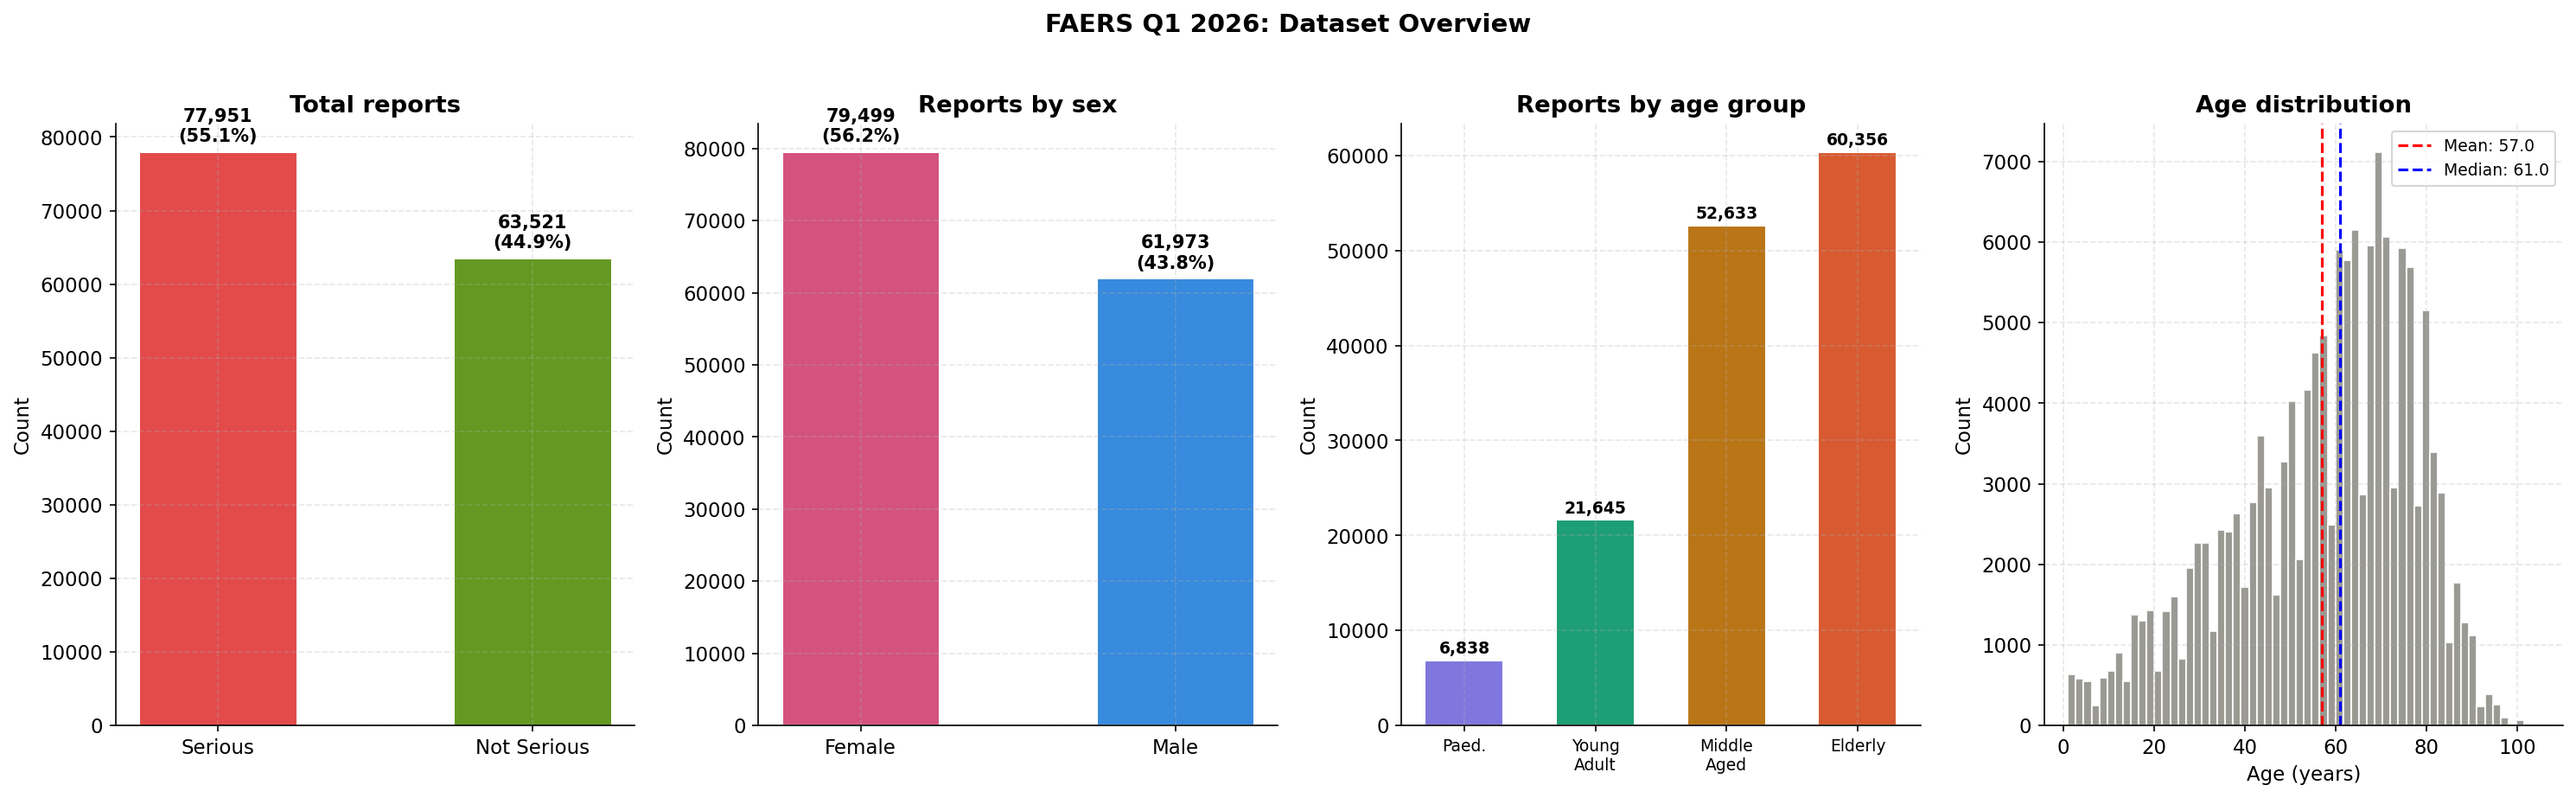

Saved → plots/01_dataset_overview.png


In [26]:
# ============================================================
# PLOT 1: DATASET OVERVIEW
# 4 panels: total counts, sex split, age group split, target
# ============================================================

# ── Clean style settings ─────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 150,
})

COLORS = {
    'male'      : '#378ADD',
    'female'    : '#D4537E',
    'serious'   : '#E24B4A',
    'not_serious': '#639922',
    'elderly'   : '#D85A30',
    'middle'    : '#BA7517',
    'young'     : '#1D9E75',
    'paediatric': '#7F77DD',
    'neutral'   : '#888780',
}

AGE_ORDER = ['paediatric', 'young_adult', 'middle_aged', 'elderly']


fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('FAERS Q1 2026: Dataset Overview',
             fontsize=14, fontweight='bold', y=1.02)

# Panel 1: Total reports
total       = len(df)
serious_n   = df['serious'].sum()
not_serious = total - serious_n

axes[0].bar(['Serious', 'Not Serious'],
            [serious_n, not_serious],
            color=[COLORS['serious'], COLORS['not_serious']],
            edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_title('Total reports', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([serious_n, not_serious]):
    axes[0].text(i, v + total*0.01,
                 f'{v:,}\n({v/total:.1%})',
                 ha='center', fontsize=10, fontweight='bold')

# Panel 2: Sex distribution
sex_counts = df['sex'].value_counts()
axes[1].bar(['Female', 'Male'],
            [sex_counts.get('F',0), sex_counts.get('M',0)],
            color=[COLORS['female'], COLORS['male']],
            edgecolor='white', width=0.5)
axes[1].set_title('Reports by sex', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (s, l) in enumerate([('F','Female'), ('M','Male')]):
    v = sex_counts.get(s, 0)
    axes[1].text(i, v + total*0.01,
                 f'{v:,}\n({v/total:.1%})',
                 ha='center', fontsize=10, fontweight='bold')

# Panel 3: Age group distribution
age_counts = df['age_group'].value_counts()
vals   = [age_counts.get(ag, 0) for ag in AGE_ORDER]
colors = [COLORS['paediatric'], COLORS['young'],
          COLORS['middle'],     COLORS['elderly']]
axes[2].bar(AGE_ORDER, vals, color=colors,
            edgecolor='white', width=0.6)
axes[2].set_title('Reports by age group', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].set_xticklabels(
    ['Paed.', 'Young\nAdult', 'Middle\nAged', 'Elderly'],
    fontsize=9)
for i, v in enumerate(vals):
    axes[2].text(i, v + total*0.005,
                 f'{v:,}', ha='center',
                 fontsize=9, fontweight='bold')

# Panel 4: Age distribution histogram
axes[3].hist(df['age_years'], bins=60,
             color=COLORS['neutral'],
             edgecolor='white', alpha=0.85)
axes[3].set_title('Age distribution', fontweight='bold')
axes[3].set_xlabel('Age (years)')
axes[3].set_ylabel('Count')
axes[3].axvline(df['age_years'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {df['age_years'].mean():.1f}")
axes[3].axvline(df['age_years'].median(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f"Median: {df['age_years'].median():.1f}")
axes[3].legend(fontsize=9)

plt.tight_layout()
plt.savefig('plots/01_dataset_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/01_dataset_overview.png")

---
This figure analyzes fairness differences by sex in adverse event severity.

* `Left panel:` compares the serious event rate between females and males, including a gap indicator and overall baseline.

* `Right panel:` shows the composition of outcomes within each sex group (serious vs non-serious in percentages).
---

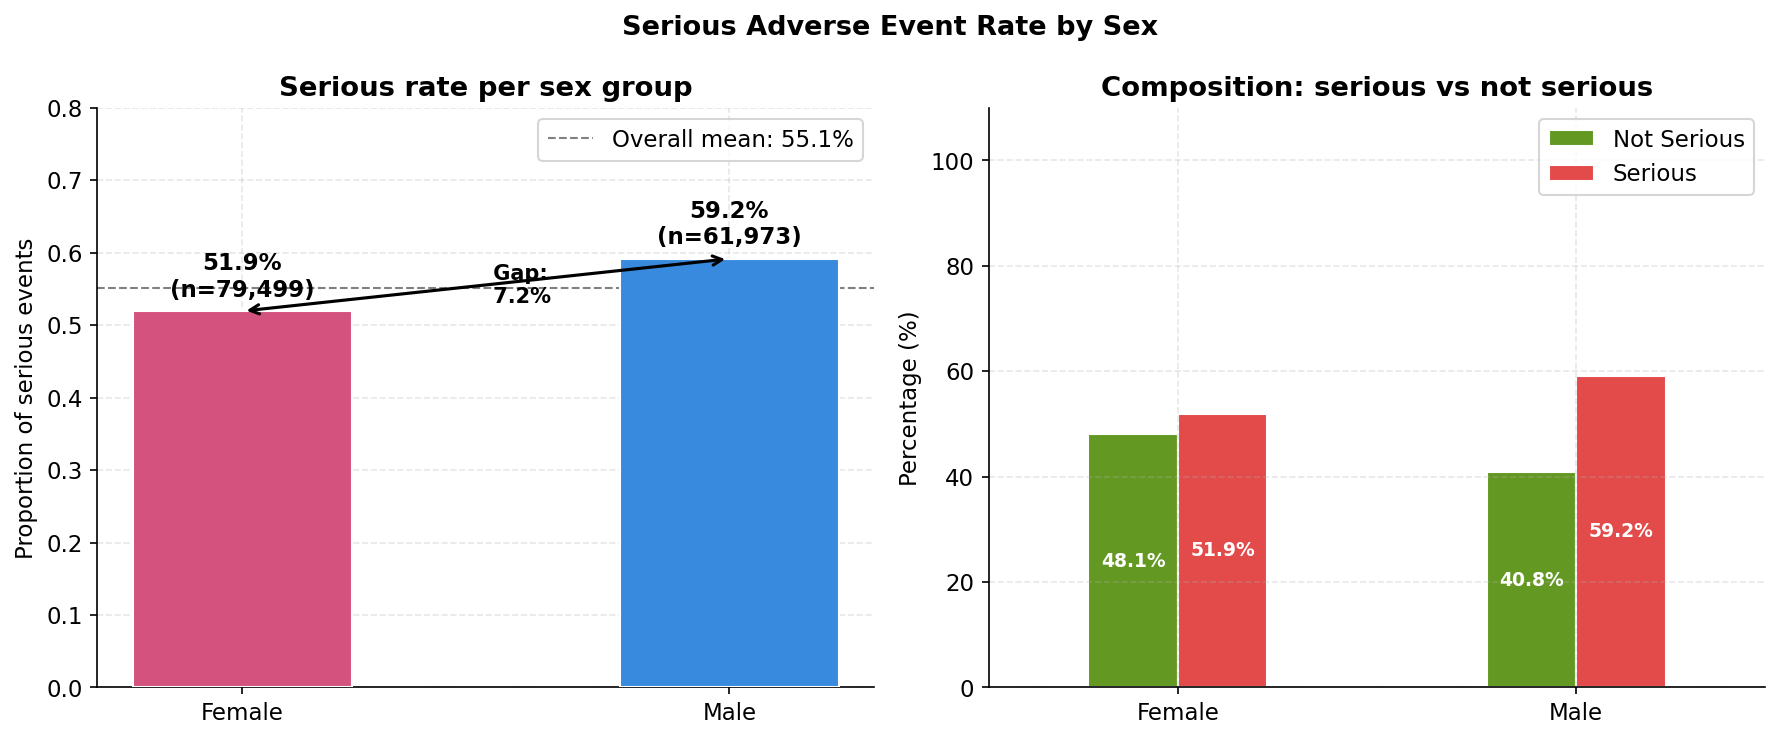

Saved → plots/02_serious_by_sex.png


In [27]:
# ============================================================
# PLOT 2: SERIOUS RATE BY SEX
# Bar chart with counts + rate label
# This is your first bias signal
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Serious Adverse Event Rate by Sex',
             fontsize=13, fontweight='bold')

# Panel 1: Serious rate bars
sex_serious = df.groupby('sex')['serious'].agg(
    rate='mean', count='count').reset_index()

bar_colors = [COLORS['female'] if s == 'F'
              else COLORS['male']
              for s in sex_serious['sex']]

bars = axes[0].bar(
    ['Female', 'Male'],
    [sex_serious.loc[sex_serious['sex']=='F', 'rate'].values[0],
     sex_serious.loc[sex_serious['sex']=='M', 'rate'].values[0]],
    color=bar_colors, edgecolor='white',
    width=0.45, zorder=3)

axes[0].set_ylim(0, 0.8)
axes[0].set_ylabel('Proportion of serious events')
axes[0].set_title('Serious rate per sex group', fontweight='bold')
axes[0].axhline(df['serious'].mean(), color='gray',
                linestyle='--', linewidth=1,
                label=f"Overall mean: {df['serious'].mean():.1%}")
axes[0].legend()

for bar, row in zip(bars, [
    sex_serious[sex_serious['sex']=='F'].iloc[0],
    sex_serious[sex_serious['sex']=='M'].iloc[0]
]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{row['rate']:.1%}\n(n={row['count']:,})",
        ha='center', fontsize=11, fontweight='bold')

# Gap annotation
f_rate = sex_serious.loc[sex_serious['sex']=='F','rate'].values[0]
m_rate = sex_serious.loc[sex_serious['sex']=='M','rate'].values[0]
axes[0].annotate('',
    xy=(1, m_rate), xytext=(0, f_rate),
    arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
axes[0].text(0.5, (f_rate + m_rate)/2,
             f' Gap:\n {abs(m_rate-f_rate):.1%}',
             ha='left', va='center', fontsize=10,
             color='black', fontweight='bold')

# Panel 2: Stacked bar showing composition
sex_comp = df.groupby(['sex', 'serious']).size().unstack()
sex_comp.index = ['Female', 'Male']
sex_comp.columns = ['Not Serious', 'Serious']
sex_comp_pct = sex_comp.div(sex_comp.sum(axis=1), axis=0) * 100

sex_comp_pct.plot(kind='bar', ax=axes[1],
    color=[COLORS['not_serious'], COLORS['serious']],
    edgecolor='white', width=0.45)
axes[1].set_title('Composition: serious vs not serious',
                  fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[1].legend(['Not Serious', 'Serious'])
axes[1].set_ylim(0, 110)
for container in axes[1].containers:
    axes[1].bar_label(container,
                      fmt='%.1f%%', fontsize=9,
                      label_type='center',
                      color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/02_serious_by_sex.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/02_serious_by_sex.png")

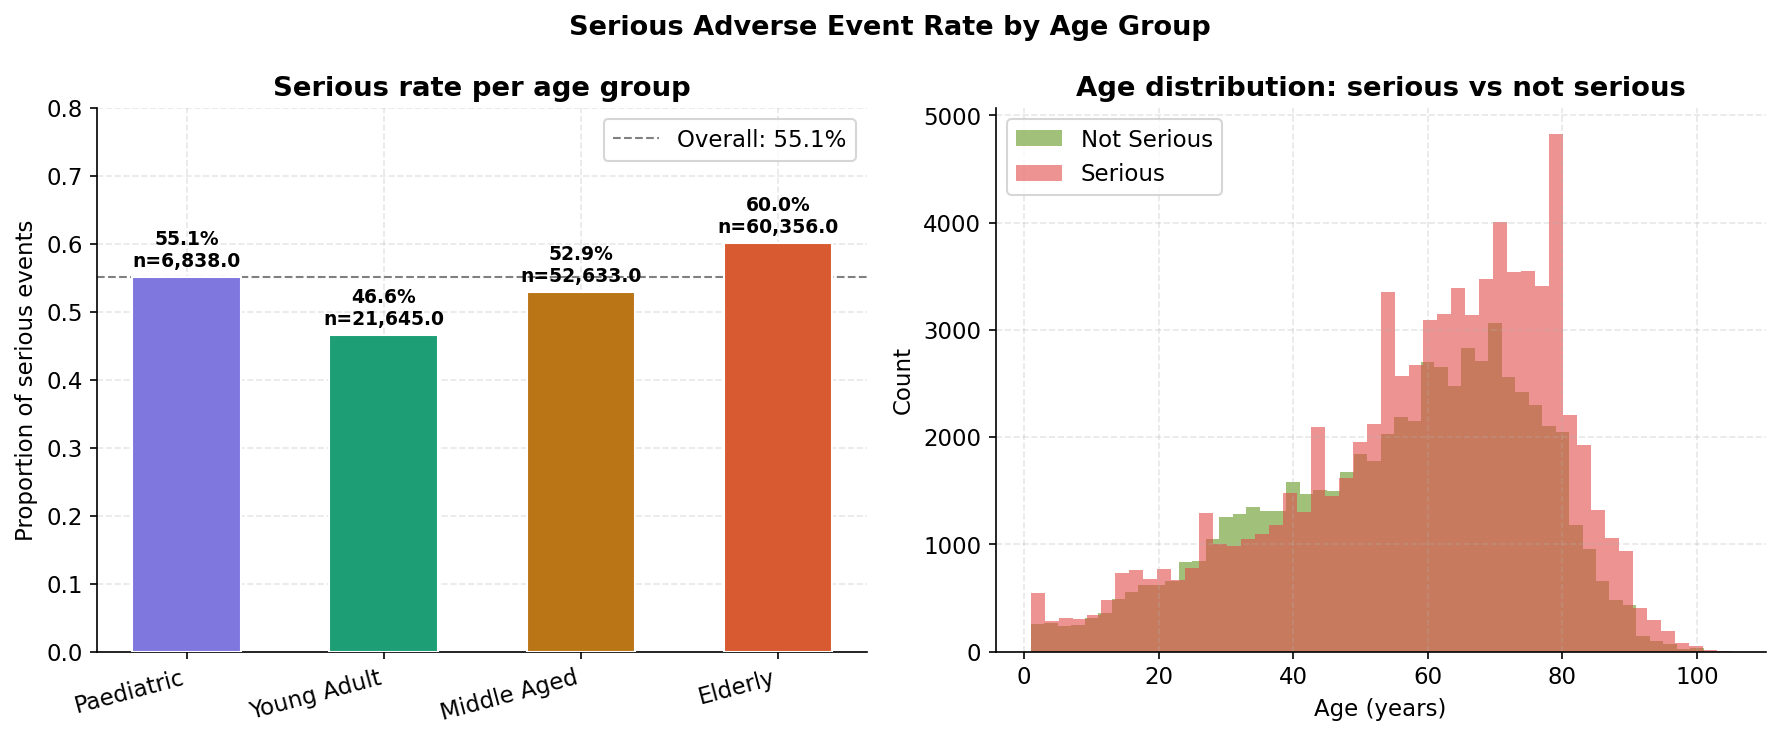

Saved → plots/03_serious_by_age.png


In [28]:
# ============================================================
# PLOT 3: SERIOUS RATE BY AGE GROUP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Serious Adverse Event Rate by Age Group',
             fontsize=13, fontweight='bold')

age_serious = (df.groupby('age_group')['serious']
               .agg(rate='mean', count='count')
               .reindex(AGE_ORDER))

age_colors = [COLORS['paediatric'], COLORS['young'],
              COLORS['middle'],     COLORS['elderly']]

# Panel 1: Rate bars
bars = axes[0].bar(
    range(len(AGE_ORDER)),
    age_serious['rate'],
    color=age_colors,
    edgecolor='white', width=0.55, zorder=3)
axes[0].set_xticks(range(len(AGE_ORDER)))
axes[0].set_xticklabels(
    ['Paediatric', 'Young Adult', 'Middle Aged', 'Elderly'],
    rotation=15, ha='right')
axes[0].set_ylim(0, 0.8)
axes[0].set_ylabel('Proportion of serious events')
axes[0].set_title('Serious rate per age group',
                  fontweight='bold')
axes[0].axhline(df['serious'].mean(), color='gray',
                linestyle='--', linewidth=1,
                label=f"Overall: {df['serious'].mean():.1%}")
axes[0].legend()

for bar, (ag, row) in zip(bars, age_serious.iterrows()):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.015,
        f"{row['rate']:.1%}\nn={row['count']:,}",
        ha='center', fontsize=9, fontweight='bold')

# Panel 2 — Age distribution split by serious
df_s  = df[df['serious']==1]
df_ns = df[df['serious']==0]
axes[1].hist(df_ns['age_years'], bins=50, alpha=0.6,
             color=COLORS['not_serious'],
             label='Not Serious', edgecolor='none')
axes[1].hist(df_s['age_years'],  bins=50, alpha=0.6,
             color=COLORS['serious'],
             label='Serious', edgecolor='none')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].set_title('Age distribution: serious vs not serious',
                  fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/03_serious_by_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/03_serious_by_age.png")

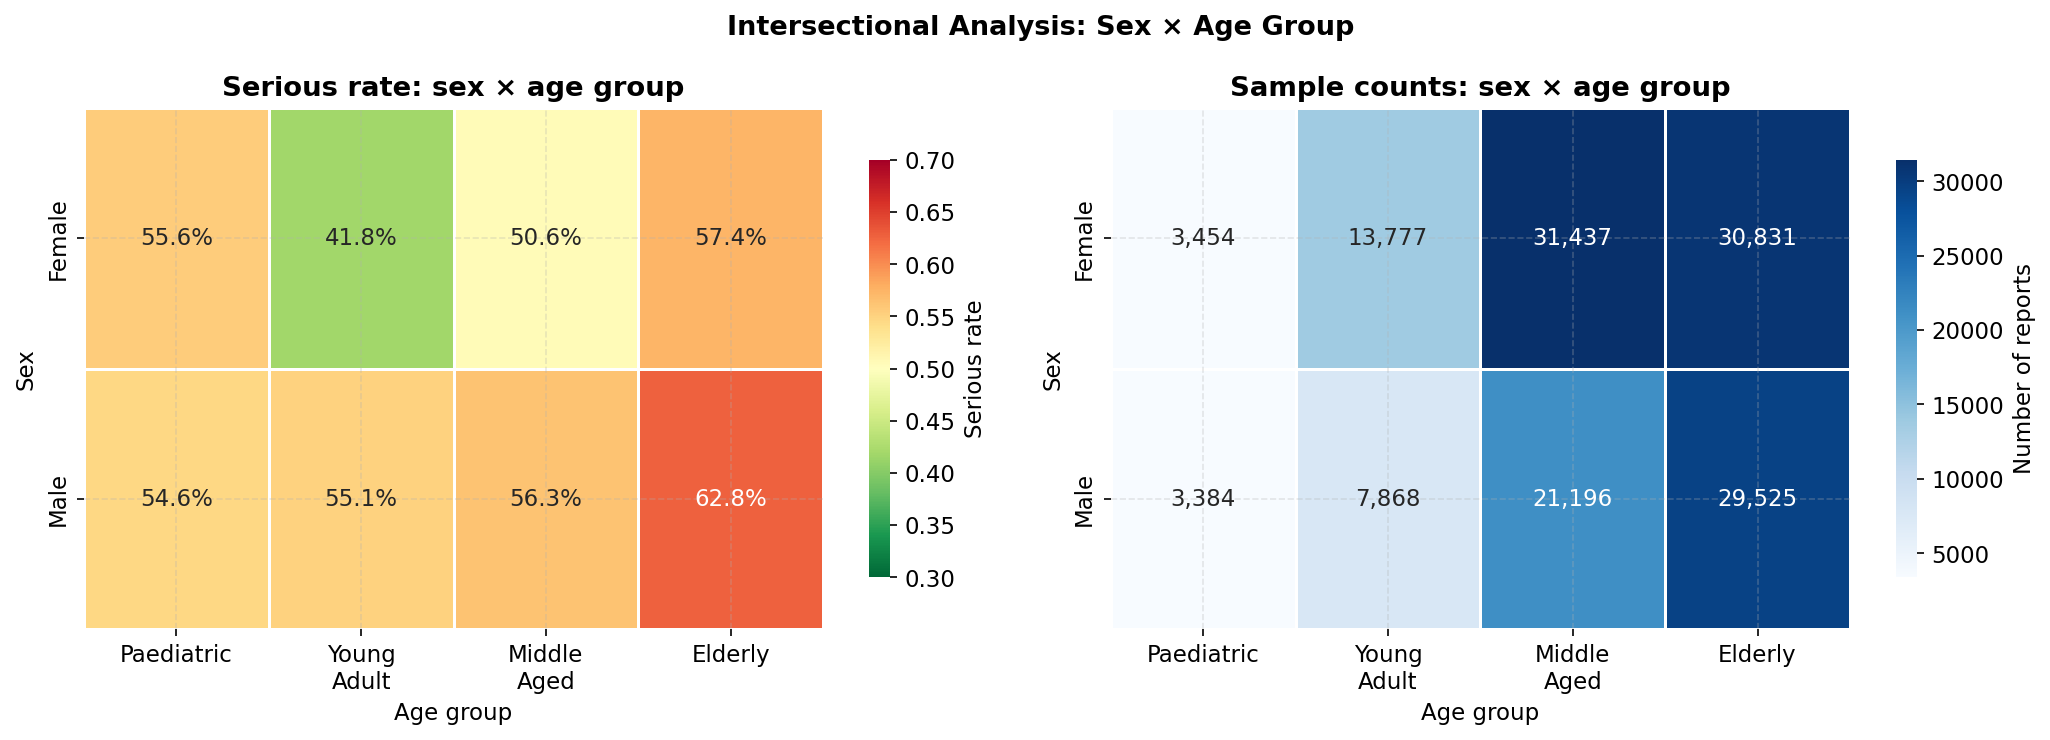

Saved → plots/04_intersectional_heatmap.png


In [29]:
# ============================================================
# PLOT 4: INTERSECTIONAL HEATMAP (sex × age group)
# This is your key pre-modelling finding
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Intersectional Analysis: Sex × Age Group',
             fontsize=13, fontweight='bold')

# Panel 1: Serious rate heatmap
pivot_rate = (df.groupby(['sex', 'age_group'])['serious']
              .mean()
              .unstack()
              .reindex(columns=AGE_ORDER))
pivot_rate.index = ['Female', 'Male']

sns.heatmap(
    pivot_rate,
    ax=axes[0],
    annot=True, fmt='.1%',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='white',
    vmin=0.3, vmax=0.7,
    cbar_kws={'label': 'Serious rate', 'shrink': 0.8})
axes[0].set_title('Serious rate: sex × age group',
                  fontweight='bold')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('Sex')
axes[0].set_xticklabels(
    ['Paediatric','Young\nAdult','Middle\nAged','Elderly'],
    rotation=0)

# Panel 2: Count heatmap
pivot_count = (df.groupby(['sex', 'age_group'])['serious']
               .count()
               .unstack()
               .reindex(columns=AGE_ORDER))
pivot_count.index = ['Female', 'Male']

sns.heatmap(
    pivot_count,
    ax=axes[1],
    annot=True, fmt=',',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Number of reports', 'shrink': 0.8})
axes[1].set_title('Sample counts: sex × age group',
                  fontweight='bold')
axes[1].set_xlabel('Age group')
axes[1].set_ylabel('Sex')
axes[1].set_xticklabels(
    ['Paediatric','Young\nAdult','Middle\nAged','Elderly'],
    rotation=0)

plt.tight_layout()
plt.savefig('plots/04_intersectional_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/04_intersectional_heatmap.png")

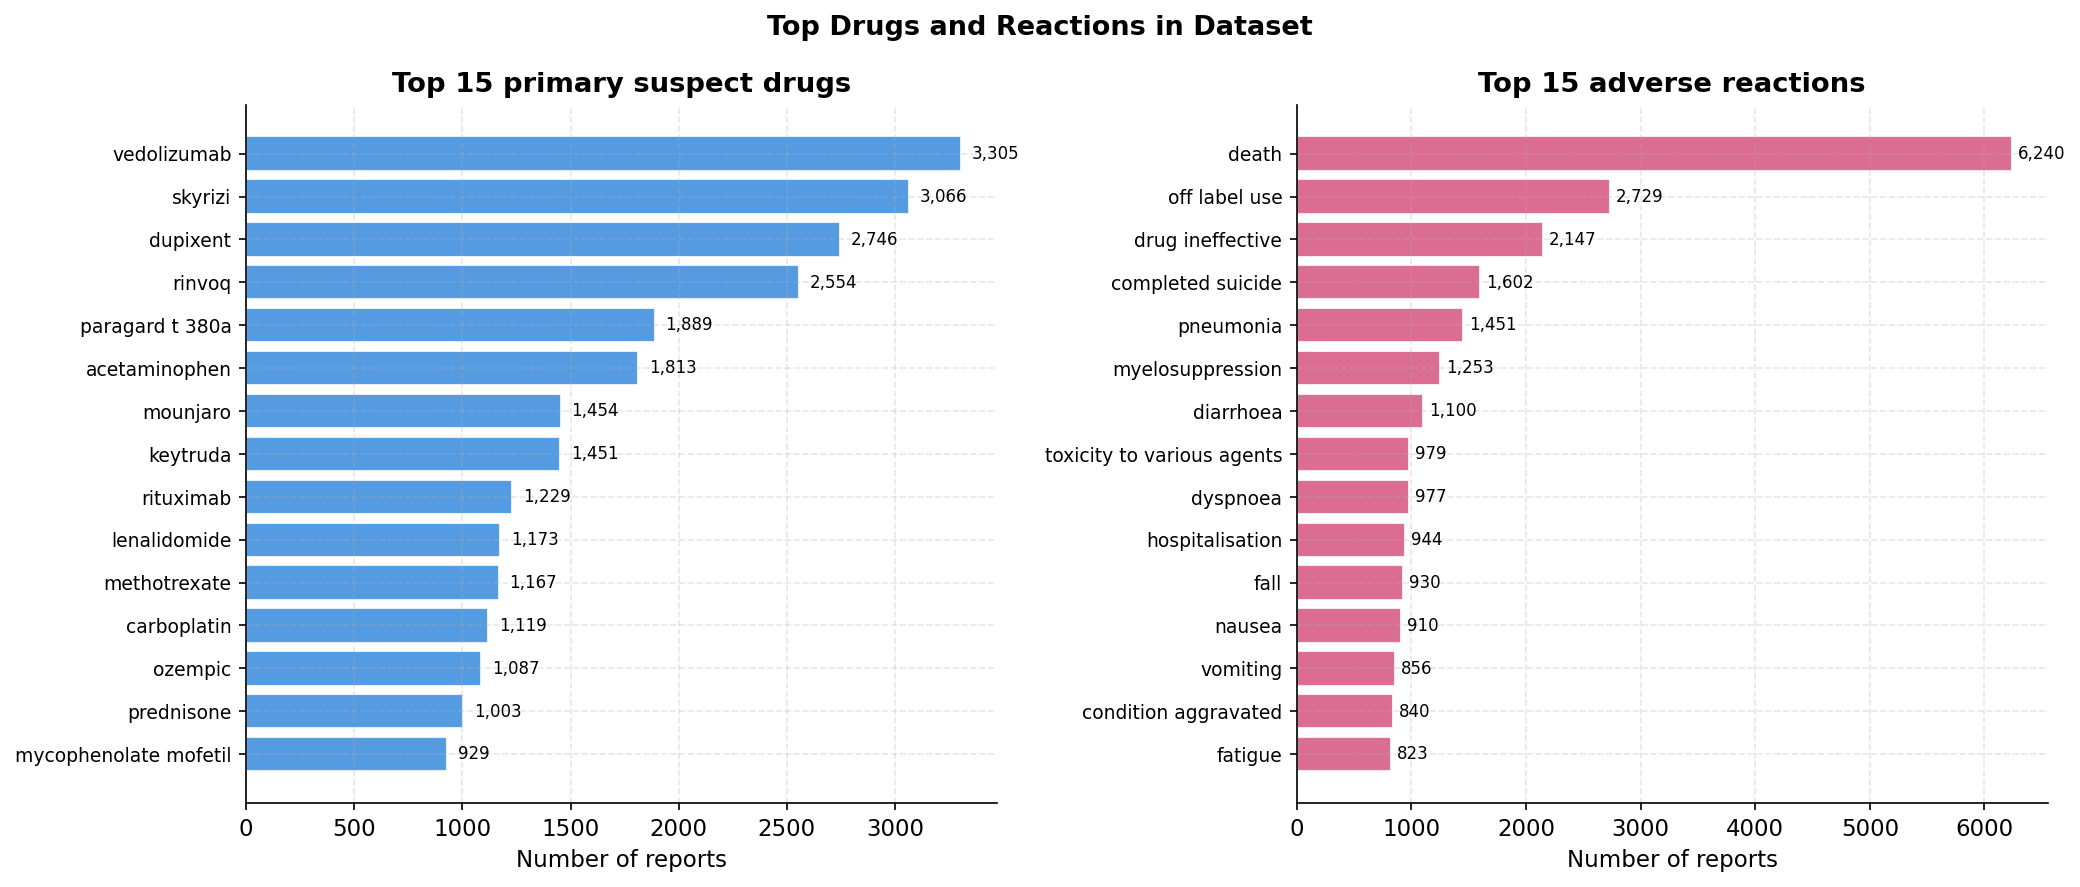

Saved → plots/05_top_drugs_reactions.png


In [30]:
# ============================================================
# PLOT 5: TOP DRUGS AND REACTIONS
# What is actually in the data medically
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Top Drugs and Reactions in Dataset',
             fontsize=13, fontweight='bold')

# Panel 1: Top 15 drugs
top_drugs = (df['drug_name']
             .value_counts()
             .head(15))
axes[0].barh(range(len(top_drugs)),
             top_drugs.values,
             color=COLORS['male'], alpha=0.85,
             edgecolor='white')
axes[0].set_yticks(range(len(top_drugs)))
axes[0].set_yticklabels(top_drugs.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of reports')
axes[0].set_title('Top 15 primary suspect drugs',
                  fontweight='bold')
for i, v in enumerate(top_drugs.values):
    axes[0].text(v + 50, i, f'{v:,}',
                 va='center', fontsize=8)

# Panel 2: Top 15 reactions
top_reacs = (df['reaction']
             .value_counts()
             .head(15))
axes[1].barh(range(len(top_reacs)),
             top_reacs.values,
             color=COLORS['female'], alpha=0.85,
             edgecolor='white')
axes[1].set_yticks(range(len(top_reacs)))
axes[1].set_yticklabels(top_reacs.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Number of reports')
axes[1].set_title('Top 15 adverse reactions',
                  fontweight='bold')
for i, v in enumerate(top_reacs.values):
    axes[1].text(v + 50, i, f'{v:,}',
                 va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plots/05_top_drugs_reactions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plots/05_top_drugs_reactions.png")

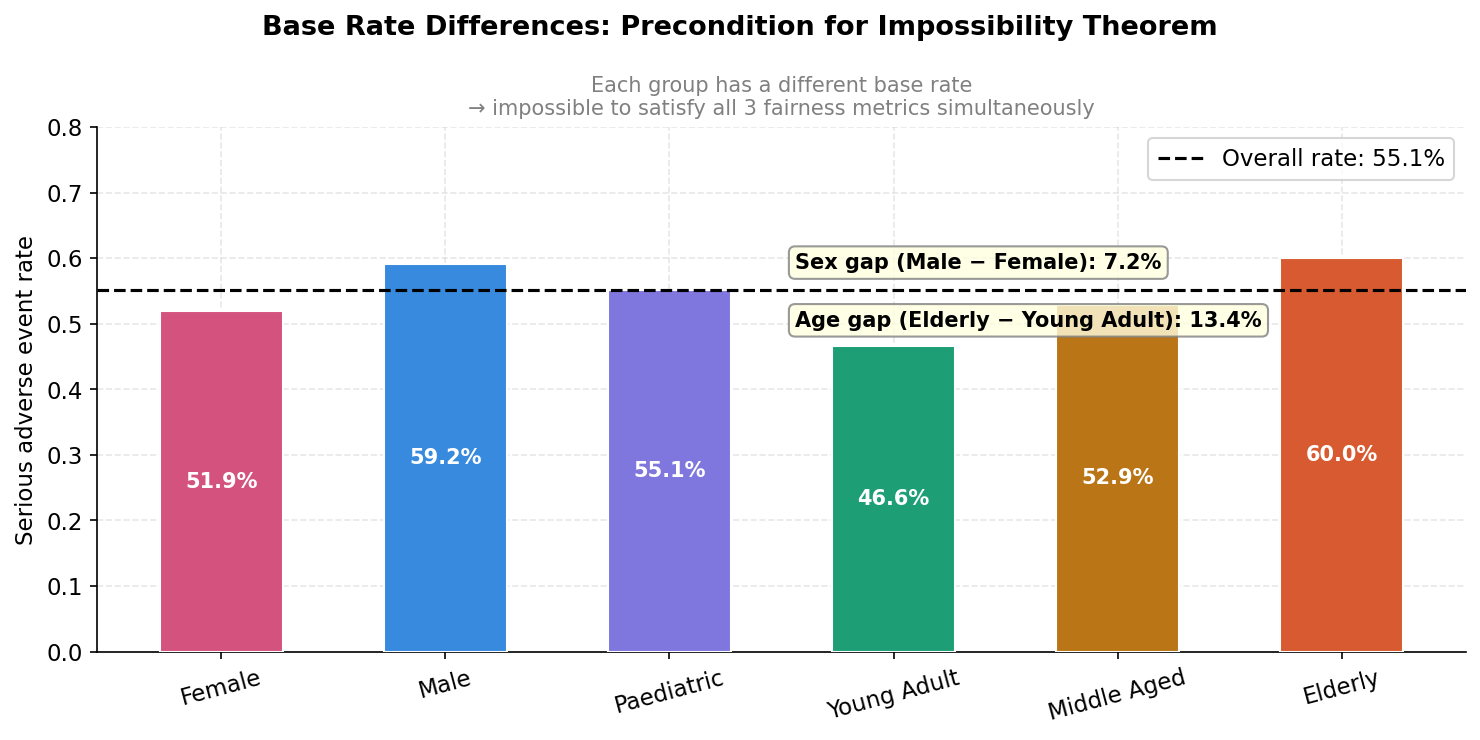

Saved → plots/06_base_rate_differences.png

Sex gap  (Male − Female)          : 7.2%
Age gap  (Elderly − Young Adult)  : 13.4%
Overall serious rate              : 55.1%


In [31]:
# ============================================================
# PLOT 6: BASE RATE DIFFERENCE SUMMARY
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(
    'Base Rate Differences: Precondition for Impossibility Theorem',
    fontsize=13, fontweight='bold')

groups = [
    'Female', 'Male',
    'Paediatric', 'Young Adult', 'Middle Aged', 'Elderly'
]

rates = [
    df[df['sex']=='F']['serious'].mean(),
    df[df['sex']=='M']['serious'].mean(),
    df[df['age_group']=='paediatric']['serious'].mean(),
    df[df['age_group']=='young_adult']['serious'].mean(),
    df[df['age_group']=='middle_aged']['serious'].mean(),
    df[df['age_group']=='elderly']['serious'].mean(),
]

bar_colors = [
    COLORS['female'],     COLORS['male'],
    COLORS['paediatric'], COLORS['young'],
    COLORS['middle'],     COLORS['elderly']
]

bars = ax.bar(groups, rates, color=bar_colors,
              edgecolor='white', width=0.55, zorder=3)

overall = df['serious'].mean()
ax.axhline(overall, color='black',
           linestyle='--', linewidth=1.5,
           label=f'Overall rate: {overall:.1%}', zorder=4)

ax.set_ylim(0, 0.8)
ax.set_ylabel('Serious adverse event rate')
ax.set_title(
    'Each group has a different base rate\n'
    '→ impossible to satisfy all 3 fairness metrics simultaneously',
    fontsize=10, color='gray')
ax.legend()
ax.tick_params(axis='x', rotation=15)

for bar, rate in zip(bars, rates):
    color = 'white' if rate > 0.4 else 'black'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f'{rate:.1%}',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color=color)

# ── FIXED gap annotations ────────────────────────────────
# Sex gap: Male minus Female
sex_gap = abs(rates[1] - rates[0])          # Male - Female

# Age gap: Elderly minus Young Adult (most extreme age pair)
age_gap = abs(rates[5] - rates[3])          # Elderly - YoungAdult
#               ↑ index 5            ↑ index 3
#            Elderly             Young Adult

ax.text(0.51, 0.73,
        f'Sex gap (Male − Female): {sex_gap:.1%}',
        transform=ax.transAxes,
        fontsize=10, fontweight='bold',
        color='black',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='lightyellow',
                  edgecolor='gray', alpha=0.8))

ax.text(0.51, 0.62,
        f'Age gap (Elderly − Young Adult): {age_gap:.1%}',
        transform=ax.transAxes,
        fontsize=10, fontweight='bold',
        color='black',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='lightyellow',
                  edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig('plots/06_base_rate_differences.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → plots/06_base_rate_differences.png')
print()
print(f'Sex gap  (Male − Female)          : {sex_gap:.1%}')
print(f'Age gap  (Elderly − Young Adult)  : {age_gap:.1%}')
print(f'Overall serious rate              : {overall:.1%}')

In [32]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print()
print("=" * 55)
print("ALL EXPLORATORY PLOTS SAVED")
print("=" * 55)
print("plots/01_dataset_overview.png")
print("plots/02_serious_by_sex.png")
print("plots/03_serious_by_age.png")
print("plots/04_intersectional_heatmap.png")
print("plots/05_top_drugs_reactions.png")
print("plots/06_base_rate_differences.png")
print()
print("Key numbers for your report:")
print(f"  Total reports   : {len(df):,}")
print(f"  Overall serious : {df['serious'].mean():.1%}")
print(f"  Female serious  : {df[df['sex']=='F']['serious'].mean():.1%}")
print(f"  Male serious    : {df[df['sex']=='M']['serious'].mean():.1%}")
print(f"  Sex gap         : {abs(df[df['sex']=='M']['serious'].mean() - df[df['sex']=='F']['serious'].mean()):.1%}")
print(f"  Elderly serious : {df[df['age_group']=='elderly']['serious'].mean():.1%}")
print(f"  Young serious   : {df[df['age_group']=='young_adult']['serious'].mean():.1%}")
print(f"  Age gap         : {abs(df[df['age_group']=='elderly']['serious'].mean() - df[df['age_group']=='young_adult']['serious'].mean()):.1%}")


ALL EXPLORATORY PLOTS SAVED
plots/01_dataset_overview.png
plots/02_serious_by_sex.png
plots/03_serious_by_age.png
plots/04_intersectional_heatmap.png
plots/05_top_drugs_reactions.png
plots/06_base_rate_differences.png

Key numbers for your report:
  Total reports   : 141,472
  Overall serious : 55.1%
  Female serious  : 51.9%
  Male serious    : 59.2%
  Sex gap         : 7.2%
  Elderly serious : 60.0%
  Young serious   : 46.6%
  Age gap         : 13.4%


In [33]:
PROCESSED_PATH = '/content/drive/MyDrive/Ethics project/processed/'
import os
os.makedirs(PROCESSED_PATH, exist_ok=True)

# Save the merged clean dataframe only
df.to_csv(PROCESSED_PATH + 'df_clean.csv', index=False)

print('=' * 50)
print('NOTEBOOK 01 COMPLETE')
print('=' * 50)
print(f'Clean merged dataframe saved')
print(f'Total rows    : {len(df):,}')
print(f'Columns       : {df.columns.tolist()}')
print(f'Serious rate  : {df["serious"].mean():.1%}')
print()

NOTEBOOK 01 COMPLETE
Clean merged dataframe saved
Total rows    : 141,472
Columns       : ['primaryid', 'age_years', 'sex', 'serious', 'reaction', 'drug_name', 'age_group']
Serious rate  : 55.1%



In [35]:
 !cp '/content/drive/MyDrive/Ethics project/01_Data_Exploration.ipynb' .

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'kulsoom2526'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 145 (delta 56), reused 0 (delta 0), pack-reused 3 (from 1)
Receiving objects: 100% (145/145), 54.66 MiB | 2.82 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Updating files: 100% (22/22), done.
/content/kulsoom2526/Notebooks
